# Lab 3: PyTorch for Cat vs Dog Faces

This notebook is the next step after Labs 1 and 2, but it is self-contained.

- Lab 1 worked with image arrays, normalization, and a hand-crafted feature matrix.
- Lab 2 worked with metadata tables, split handling, and label mapping in Pandas.
- Lab 3 turns the same kind of image workflow into PyTorch tensors, datasets, loaders, and a trainable CNN.

In this notebook, you will train a small **binary image classifier** with PyTorch.

We will focus on the core training pipeline:

- turning a metadata table into training inputs
- converting image files into PyTorch tensors
- building `Dataset` and `DataLoader` objects
- defining a simple CNN model
- choosing a loss and optimizer
- writing training and evaluation loops
- comparing learned features with handcrafted NumPy features from Lab 1

Set the fixed random seed `1234` in the first code cell. Each notebook uses it for sampling, split suggestions, and visualization so the results are reproducible.

**Questions in this lab**

1. Map labels to integers in the dataframe loaded in this notebook
2. Build a dataset that returns tensors
3. Create train, validation, and test DataLoaders
4. Inspect one mini-batch
5. Define a simple CNN classifier
6. Set up loss, optimizer, and device
7. Complete one training epoch
8. Evaluate the model on a validation or test loader
9. Train for a few epochs and compare it with the Lab 1 NumPy feature pipeline


In [79]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from lab_utils.visualization import (
    extract_feature_maps,
    plot_feature_maps_like_reference,
    plot_training_history,
    show_tensor_batch,
)

def find_project_root() -> Path:
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (candidate / "data").exists():
            return candidate
    return Path.cwd().resolve()

PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / "data"
METADATA_PATH = DATA_ROOT / "metadata.csv"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)

LABELS = ("cat", "dog")
SPLITS = ("train", "val", "test")
SEED = 1234
EPOCHS = 20
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
NUMPY_PRED_PATH = ARTIFACT_DIR / "lab3_pytorch_predictions.csv"

def seed_index(length: int, offset: int = 0) -> int:
    if length <= 0:
        raise ValueError("Cannot choose an index from an empty collection.")
    return int((SEED + offset) % length)

def build_metadata_from_folders(data_root: Path) -> pd.DataFrame:
    rows = []
    for split in SPLITS:
        for label in LABELS:
            label_dir = data_root / split / label
            for path in sorted(label_dir.glob("*.jpg")) + sorted(label_dir.glob("*.png")):
                with Image.open(path) as image:
                    image = image.convert("RGB")
                    width, height = image.size
                rows.append(
                    {
                        "filepath": str(path.relative_to(data_root)),
                        "label": label,
                        "split": split,
                        "width": width,
                        "height": height,
                    }
                )
    return pd.DataFrame(rows)

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        "Dataset not found. Place the prepared subset at data/."
    )

if METADATA_PATH.exists():
    df = pd.read_csv(METADATA_PATH)
else:
    df = build_metadata_from_folders(DATA_ROOT)

print(f"Fixed seed: {SEED}")
print(df.head())
print(df["split"].value_counts())


Fixed seed: 1234
                 filepath label  split  width  height
0  train/cat/cat_0000.jpg   cat  train     64      64
1  train/cat/cat_0001.jpg   cat  train     64      64
2  train/cat/cat_0002.jpg   cat  train     64      64
3  train/cat/cat_0003.jpg   cat  train     64      64
4  train/cat/cat_0004.jpg   cat  train     64      64
split
train    420
val       90
test      90
Name: count, dtype: int64


## Question 1: Turn string labels into integer labels

Complete `build_label_mapping(...)`.

It should:

- a dictionary `label_to_index`
- a dataframe with `label_id`
- train, validation, and test dataframes
- a new column `label_id`

Use `cat -> 0` and `dog -> 1`.

This is the same Pandas-style label handling from Lab 2, but now the labels become the targets for PyTorch training.


In [80]:
def build_label_mapping(frame: pd.DataFrame) -> tuple[
    dict[str, int], pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame
]:
    # cat -> 0, dog -> 1
    label_to_index = {label: idx for idx, label in enumerate(LABELS)}

    labelled = frame.copy()
    labelled["label_id"] = labelled["label"].map(label_to_index)

    train_df = labelled[labelled["split"] == "train"].reset_index(drop=True)
    val_df = labelled[labelled["split"] == "val"].reset_index(drop=True)
    test_df = labelled[labelled["split"] == "test"].reset_index(drop=True)

    return label_to_index, labelled, train_df, val_df, test_df
label_to_index, df, train_df, val_df, test_df = build_label_mapping(df)

print(train_df.head())


                 filepath label  split  width  height  label_id
0  train/cat/cat_0000.jpg   cat  train     64      64         0
1  train/cat/cat_0001.jpg   cat  train     64      64         0
2  train/cat/cat_0002.jpg   cat  train     64      64         0
3  train/cat/cat_0003.jpg   cat  train     64      64         0
4  train/cat/cat_0004.jpg   cat  train     64      64         0


## Question 2: Build a dataset that returns tensors

In Lab 1, you turned images into NumPy arrays and normalized pixel values.
Now do the same preprocessing in PyTorch.

Complete:

- `image_to_tensor`
- `CatsDogsDataset.__getitem__`

Your dataset should return:

- an image tensor with shape `(3, 64, 64)`
- an integer label tensor


In [81]:
def image_to_tensor(path: Path) -> torch.Tensor:
    image = Image.open(path).convert("RGB")
    image = image.resize((64, 64))

    image_array = np.array(image, dtype=np.float32) / 255.0

    tensor = torch.tensor(image_array)
    tensor = tensor.permute(2, 0, 1)  # (H,W,C) -> (C,H,W)

    return tensor


class CatsDogsDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, data_root: Path):
        self.frame = frame.reset_index(drop=True)
        self.data_root = data_root

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]

        image_path = self.data_root / row["filepath"]
        image_tensor = image_to_tensor(image_path)

        label_tensor = torch.tensor(
            row["label_id"],
            dtype=torch.long
        )

        return image_tensor, label_tensor

## Question 3: Create DataLoaders

Complete `build_dataloaders(...)`.

Turn the metadata table in this notebook into training inputs.

Build three DataLoaders:

- training loader with `shuffle=True`
- validation loader with `shuffle=False`
- test loader with `shuffle=False`

Use a batch size of `32`.

Reuse `train_df`, `val_df`, and `test_df` here.


In [82]:
BATCH_SIZE = 32
train_loader_generator = torch.Generator().manual_seed(SEED)


def build_dataloaders(
    train_df,
    val_df,
    test_df,
    data_root,
    batch_size=32,
    seed=SEED,
    dataset_cls=CatsDogsDataset,
):

    train_dataset = dataset_cls(train_df, data_root)
    val_dataset = dataset_cls(val_df, data_root)
    test_dataset = dataset_cls(test_df, data_root)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=train_loader_generator
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, val_loader, test_loader


## Question 4: Inspect one mini-batch

Complete `inspect_first_batch(...)`.

Pull one batch from the training loader and verify:

- image batch shape
- label batch shape
- image dtype
- label dtype


In [83]:
def inspect_first_batch(loader: DataLoader):
    if loader is None:
        raise ValueError("Complete Question 3 before inspecting a batch.")

    batch_images, batch_labels = next(iter(loader))

    print("Image batch:", batch_images.shape, batch_images.dtype)
    print("Label batch:", batch_labels.shape, batch_labels.dtype)

    assert batch_images.ndim == 4
    assert batch_images.shape[1] == 3
    assert batch_labels.dtype == torch.long

    return batch_images, batch_labels


## Shape checkpoint

Before moving on to the CNN, check that your mini-batch looks right:

- images: `(batch, 3, 64, 64)`
- labels: integer class IDs with dtype `torch.long`

If either one looks off, fix the dataset or preprocessing step before Question 5.


## Question 5: Define a simple CNN classifier

In Lab 1, the features were hand-crafted.
Here, the CNN learns its own features automatically.

Complete the model below.

Suggested architecture:

- stage 1: `Conv2d(3, 16, kernel_size=3, padding=1)` -> `ReLU` -> `MaxPool2d(2)`
- stage 2: `Conv2d(16, 32, kernel_size=3, padding=1)` -> `ReLU` -> `MaxPool2d(2)`
- classifier: `Flatten` -> `Linear(32 * 16 * 16, 64)` -> `ReLU` -> `Linear(64, 2)`


In [84]:
class CatsDogsSimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.stage1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.stage2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.stage1(x)
        x = self.stage2(x)
        return self.classifier(x)


## Question 6: Set up the training ingredients

Complete `setup_training(...)`.

Choose:

- a device (`cuda` if available, otherwise `cpu`)
- a loss function
- an optimizer

Use `CrossEntropyLoss` and `Adam` for this lab.

Set the learning rate to `1e-3`.


In [85]:
def setup_training(
    model,
    device=None,
    learning_rate=1e-3
):
    if device is None:
        device = torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    return device, model, criterion, optimizer
model = CatsDogsSimpleCNN()

device, model, criterion, optimizer = setup_training(model)

print("Using device:", device)

Using device: cpu


## Question 7: Complete one training epoch

Fill in the missing logic for:

- zeroing gradients
- forward pass
- loss computation
- backward pass
- optimizer step
- batch accuracy tracking


In [86]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(images)

        loss = criterion(logits, labels)

        loss.backward()

        optimizer.step()

        predictions = torch.argmax(logits, dim=1)

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_correct += (predictions == labels).sum().item()
        total_examples += batch_size

    average_loss = total_loss / total_examples
    average_accuracy = total_correct / total_examples

    return average_loss, average_accuracy

## Question 8: Evaluate one model on one loader

Complete `evaluate(...)`.

It should run the model in evaluation mode on one loader and return average loss and accuracy.

Reflection prompts:

1. Did the simple CNN outperform the Lab 1 NumPy feature pipeline?
2. Did the model start to overfit?
3. What would you try next: horizontal flips, more filters, one more conv block, or longer training?
4. Why might learned features from a CNN outperform the handcrafted NumPy features from Lab 1?


In [87]:
def evaluate(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)

            loss = criterion(logits, labels)

            predictions = torch.argmax(logits, dim=1)

            batch_size = labels.size(0)

            total_loss += loss.item() * batch_size
            total_correct += (predictions == labels).sum().item()
            total_examples += batch_size

    average_loss = total_loss / total_examples
    average_accuracy = total_correct / total_examples

    return average_loss, average_accuracy

## Question 9: Train for a few epochs and evaluate

Complete `run_training_experiment(...)`.

It should train for a few epochs, evaluate on the test set.

Reflection prompts:

1. Did the model start to overfit?
2. What would you try next: horizontal flips, more filters, one more conv block, or longer training?


In [88]:
def run_training_experiment(
    model,
    train_loader,
    val_loader,
    test_loader,
    criterion,
    optimizer,
    device,
    epochs=5,
    plot=True,
):
    history = []

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device
        )

        val_loss, val_acc = evaluate(
            model,
            val_loader,
            criterion,
            device
        )

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc
        })

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    test_loss, test_acc = evaluate(
        model,
        test_loader,
        criterion,
        device
    )

    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")

    if plot:
        plot_training_history(history)

    return history, test_loss, test_acc


## Optional Visualization: Feature Maps Like the AlexNet Notebook

The main lab now uses a simple CNN, so we can visualize feature maps from the trained model directly.

The visualization utility is intentionally styled like the tiled activation-grid view from the referenced AlexNet notebook:

- one tile per channel
- `viridis` colormap
- light gaps between maps
- fixed `vmin` and `vmax` controls so maps are easier to compare

We will inspect stage-1 and stage-2 activations for one seed-specific training image.


Selected image: train/cat/cat_0054.jpg | Label: cat
Stage 1 shape: (16, 32, 32)
Stage 2 shape: (32, 16, 16)


(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': 'Feature Maps After Stage 2'}>,
 array([[[0.926106, 0.89733 , 0.104071],
         [0.993248, 0.906157, 0.143936],
         [0.993248, 0.906157, 0.143936],
         ...,
         [0.122312, 0.633153, 0.530398],
         [0.122312, 0.633153, 0.530398],
         [0.122312, 0.633153, 0.530398]],
 
        [[0.993248, 0.906157, 0.143936],
         [0.993248, 0.906157, 0.143936],
         [0.993248, 0.906157, 0.143936],
         ...,
         [0.122312, 0.633153, 0.530398],
         [0.122312, 0.633153, 0.530398],
         [0.122312, 0.633153, 0.530398]],
 
        [[0.993248, 0.906157, 0.143936],
         [0.993248, 0.906157, 0.143936],
         [0.993248, 0.906157, 0.143936],
         ...,
         [0.122312, 0.633153, 0.530398],
         [0.122312, 0.633153, 0.530398],
         [0.122312, 0.633153, 0.530398]],
 
        ...,
 
        [[0.699415, 0.867117, 0.175971],
         [0.804182, 0.882046, 0.114965],
         [0.876168,

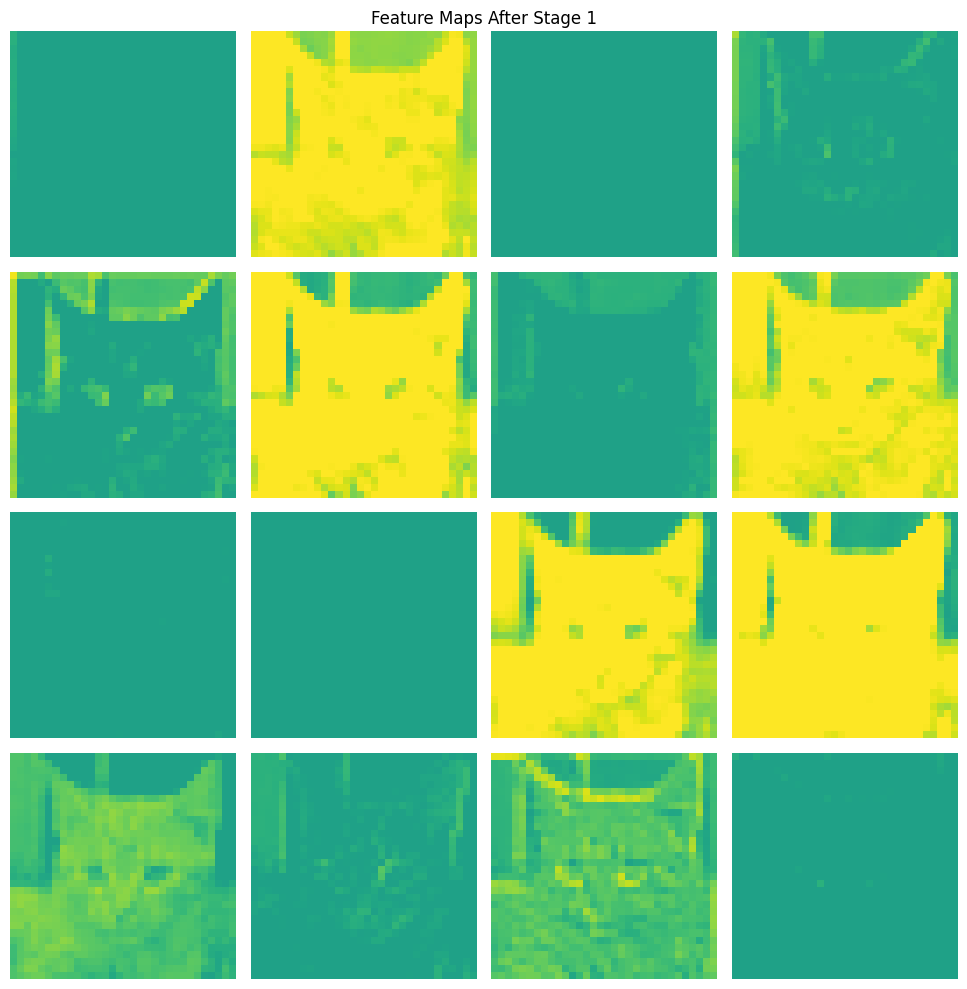

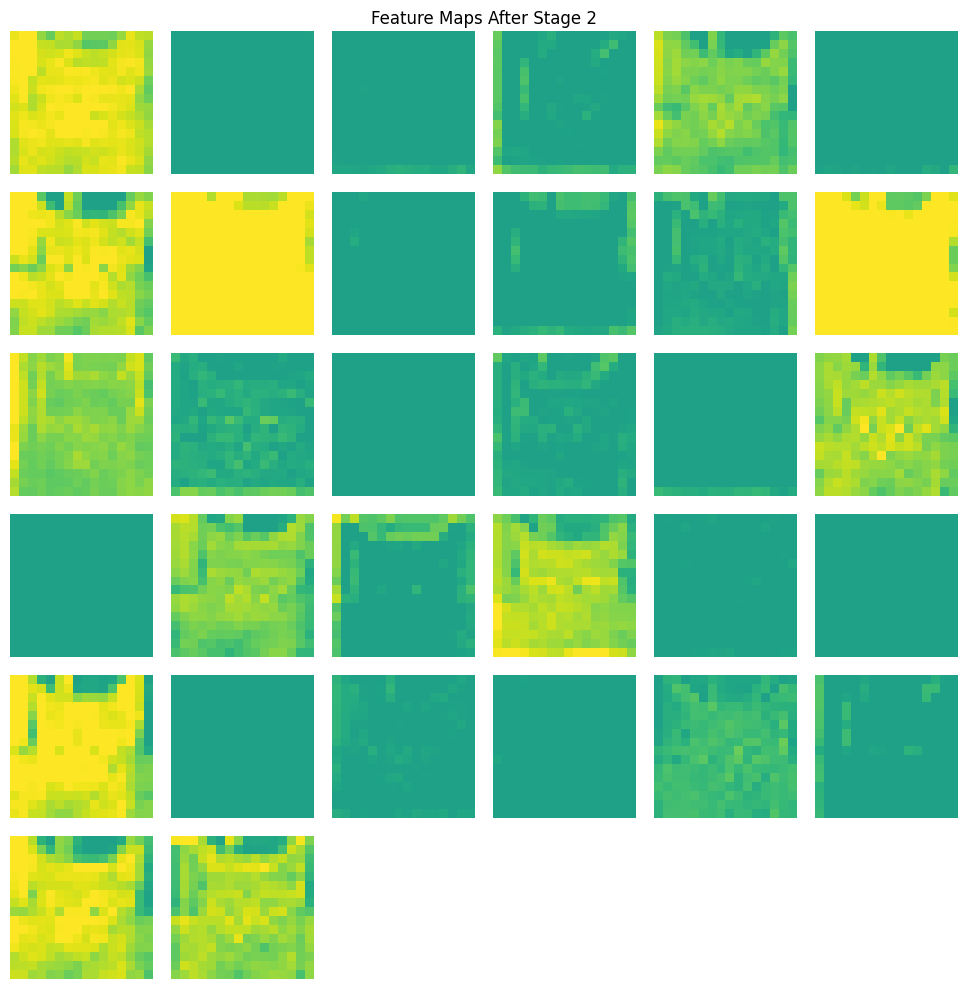

In [89]:
if device is None:
    raise ValueError("Complete Questions 5-9 first.")

model.eval()

train_dataset = CatsDogsDataset(train_df, DATA_ROOT)

feature_map_index = seed_index(len(train_dataset), offset=500)

example_image, example_label = train_dataset[feature_map_index]
example_row = train_df.iloc[feature_map_index]

print(
    f"Selected image: {example_row['filepath']} | "
    f"Label: {example_row['label']}"
)

input_tensor = example_image.unsqueeze(0).to(device)

with torch.no_grad():
    stage1_output = model.stage1(input_tensor)
    stage2_output = model.stage2(stage1_output)

stage1_maps = stage1_output.squeeze(0).cpu().numpy()
stage2_maps = stage2_output.squeeze(0).cpu().numpy()

print("Stage 1 shape:", stage1_maps.shape)
print("Stage 2 shape:", stage2_maps.shape)

plot_feature_maps_like_reference(
    stage1_maps,
    title="Feature Maps After Stage 1",
    figsize=(10,10)
)

plot_feature_maps_like_reference(
    stage2_maps,
    title="Feature Maps After Stage 2",
    figsize=(10,10)
)

## Optional extension and recap

If you finish early, try one of these:

- increase the filters from `16, 32` to `24, 48`
- add one more convolution block before the classifier
- compare stage-1 and stage-2 feature maps for the same image
- add random horizontal flips to the training data

Recap:

- Which ideas from Labs 1 and 2 showed up again in Lab 3?
- What changed when you moved from NumPy and Pandas into PyTorch?

Then record which change helped validation accuracy most and how the feature maps changed.
